# In Silico Mini Benchmark Report

## 짧은 관측 구간에서의 심박수 추정 방법 비교

### FFT, Parabolic Interpolation, Autocorrelation, Fourier Fitting의 정확도 및 계산비용 분석

## 1. 연구 배경

최근 Daphnia magna의 심박수는 기존의 사망률(mortality)이나 움직임 불능(immobilisation)과 같은 급성 독성 지표보다 더 이른 단계의 생리적 변화를 탐지할 수 있는 아치사 생리 지표(sublethal physiological endpoint)로 활용될 가능성이 제시되고 있다.  

논문 High-throughput heart rate monitoring in Daphnia magna for sublethal ecotoxicological assessment에서는 D. magna의 심장 영역에서 얻은 픽셀 밝기 변화를 시계열 신호로 변환한 뒤, 이를 이용해 심박수를 자동으로 추정하는 시스템을 구축하였다. 해당 연구에서는 약 100 fps로 1초 동안 심박 신호를 기록하고, FFT를 이용해 초기 주파수를 추정한 뒤 3차 Fourier series model에 기반한 비선형 최소제곱 fitting으로 값을 보정하였다. 최종적으로 추정된 기본 주파수(fundamental frequency)에 60을 곱해 bpm으로 변환하였다.  

이 과정에서 FFT 결과를 최종값으로 사용하지 않고 Fourier fitting을 추가한 이유는 무엇일까? FFT 스펙트럼에서 가장 큰 bin만 선택하는 단순한 peak 추정 방식은 실제 심박수를 세밀하게 추정하는 데 한계가 있을 수 있기 때문이라고 생각하였다.  

따라서 이 개인 연구에서는 특정 방법이 반드시 가장 우수하다고 전제하지 않은 상태에서 여러 주파수 추정 방법을 동일한 합성 신호 조건에서 비교하여 각 방법의 특성을 이해하고자 한다.

# 2. 연구 목적

본 연구의 목적은 짧은 관측 구간의 심박수 분석 과정을 computational simulation을 통해 이해하고, 서로 다른 주파수 추정 방법의 정확도와 계산비용 차이를 비교하는 것으로, 크게 다음 3가지 질문을 다룬다.

### Research Question 1

**1초처럼 짧은 관측 구간에서 단순 FFT peak 방식은 실제 심박수를 얼마나 정확하게 추정할 수 있는가?**

FFT가 일정한 간격의 주파수 값만 구분할 수 있기 때문에, 실제 심박수가 그 사이에 있을 때 얼마나 오차가 발생하는지 확인한다.

### Research Question 2

**FFT 이후 간단한 보간, autocorrelation 또는 nonlinear fitting을 적용하면 추정 오차를 얼마나 줄일 수 있는가?**

다음 네 가지 방법을 비교한다.

- M1: FFT peak
- M2: FFT + parabolic interpolation (포물선 보간)
- M3: autocorrelation (자기상관)
- M4: third-order Fourier fitting

### Research Question 3

**정확도가 높아질수록 계산비용은 얼마나 증가하는가?**

심박수 분석은 high-throughput system에서 반복적으로 수행되어야 하므로 정확도뿐 아니라 처리시간(latency) 역시 중요한 요소다.

따라서 각 방법의 정확도 ↔ 계산 비용 사이의 trade-off를 확인한다.

    본 실험에서는
    - synthetic heartbeat signal 생성 및 수치 계산을 위해 `NumPy`
    - 실험 결과 정리를 위해 `Pandas`
    - 결과 시각화를 위해 `Matplotlib`
    - autocorrelation 결과에서 주기적인 peak를 탐색하기 위해 `SciPy`의 `find_peaks`
    - 3차 Fourier model의 비선형 피팅 (데이터와 가장 비슷한 모양이 되도록 함수의 값을 조금씩 바꿔가며 맞추기)을 위해 `curve_fit`
    - 각 심박수 추정 방법의 실행 시간을 측정하기 위해 `time` 모듈

    을 사용한다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks
from scipy.optimize import curve_fit

import time

print("설정 완료")

설정 완료


0. 논문 기반 기본 실험 조건

In [2]:
FS = 100
# Sampling frequency = 100 Hz
# 논문의 100 fps 조건을 단순화하여 사용

MAIN_DURATION = 1.0
# 논문의 기본 관측 시간 = 1 second

# [논문에서 제시된 control range를 참고]
BPM_MIN = 275.0
BPM_MAX = 388.0

print("Sampling frequency:", FS, "Hz")
print("Main observation duration:", MAIN_DURATION, "s")
print("Heart-rate range:", BPM_MIN, "~", BPM_MAX, "bpm")

Sampling frequency: 100 Hz
Main observation duration: 1.0 s
Heart-rate range: 275.0 ~ 388.0 bpm


###**1단계. Synthetic Heartbeat Signal 만들기**

실제 Daphnia 영상 대신 정답을 알고 있는 가상 심박 신호만들기

**1-1.신호 생성 함수**

실제 Daphnia 영상에서는 심장 부근의 ROI(Region of Interest)에서 frame별 픽셀 밝기 변화를 추출하여 시간에 따른 heartbeat signal을 얻는다.

본 실험에서는 실제 영상 데이터 대신 정답 심박수(Ground Truth BPM)를 미리 정할 수 있도록 합성 신호(synthetic signal)를 생성한다. 이렇게 하면 각 알고리즘이 추정한 BPM과 실제값의 차이를 정확하게 계산할 수 있다.

먼저 입력된 BPM을 Hz 단위의 기본 주파수 f0로 변환한다.
(예:330 bpm은 330/60 = 5.5Hz 이므로 1초 동안 약 5.5회의 주기를 갖는다.)

Synthetic signal은 기본 주파수뿐 아니라 2차, 3차 고조파(harmonic)를 포함하도록 구성하여 더 복잡한 주기 신호를 생성하였다.

- *y(t)=A1​sin(2πf0​t)+A2​sin(4πf0​t+ϕ2​)+A3​sin(6πf0​t+ϕ3​)+ϵ(t)*



이는 선행 논문에서 third-order Fourier model을 사용한 것을 참고하였다.

여기서 사용한 진폭(amplitude) 1.00, 0.30, 0.15와 위상(phase) 0.5, 1.2는 시뮬레이션을 위해 임의로 설정한 값이다.

마지막으로 실제 측정 환경의 불확실성을 표현하기 위해 Gaussian noise를 추가한다.

    - duration : float
        관측 시간 (초)
    - fs : int
        sampling frequency (Hz)
    - true_bpm : float
        실제 심박수
    - noise_std : float
        Gaussian noise 표준편차
    - rng : numpy random generator
        재현 가능한 난수 생성을 위한 generator

In [3]:
def generate_daphnia_signal(
    duration=1.0,
    fs=100,
    true_bpm=330.0, #330bpm으로 실험용 심장 박동 수 설정
    noise_std=0.2,
    rng=None
):

    if rng is None:
        rng = np.random.default_rng()

    # 시간축 생성
    t = np.arange(0, duration, 1 / fs)

    # BPM → Hz
    f0 = true_bpm / 60.0

    # 3차 harmonic을 포함한 단순화된 주기 신호
    y_clean = (
        1.00 * np.sin(2 * np.pi * f0 * t)
        + 0.30 * np.sin(2 * np.pi * 2 * f0 * t + 0.5) #2차
        + 0.15 * np.sin(2 * np.pi * 3 * f0 * t + 1.2) #3차
    )

    # Gaussian noise
    noise = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=len(t)
    )

    y_noisy = y_clean + noise

    return t, y_noisy, y_clean

1-2. 테스트 신호 생성하기
- 100 fps, 1초 조건을 단순화해서 재현



In [4]:
rng = np.random.default_rng(seed=35) #난수생성기. 시작점 의미없는 랜덤숫자인 35로 고정-> 다시 생성해도 동일 noise 재현가능

t, y_noisy, y_clean = generate_daphnia_signal(
    duration=1.0,
    fs=100,
    true_bpm=330, #알고리즘 동작확인을 위해 330bpm을 Ground Truth로 정한다.
    noise_std=0.2,
    rng=rng       #앞에서 생성한 난수 생성기를 전달
)

print("데이터 개수:", len(t))
print("관측 시간:", t[-1] + 0.01, "초")

데이터 개수: 100
관측 시간: 1.0 초


1-3. 신호 파장의 시각화

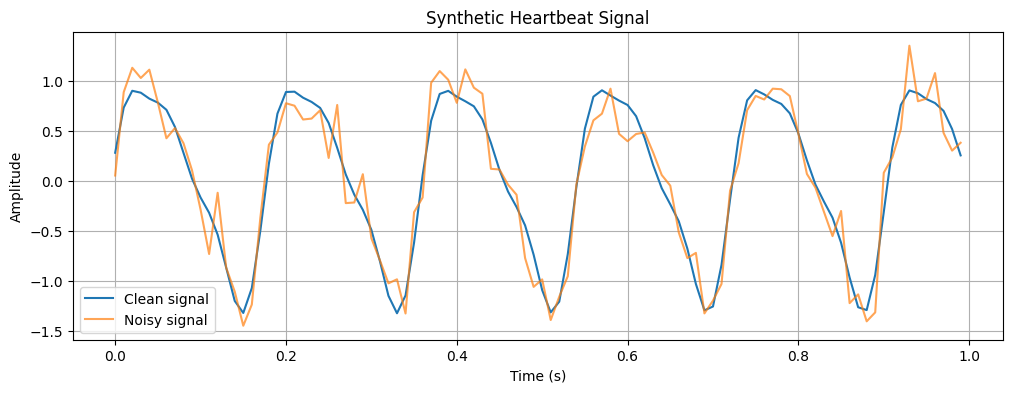

In [5]:
plt.figure(figsize=(12, 4))

plt.plot(t, y_clean, label="Clean signal") #Clean signal은 harmonic 성분만 포함한 이상적인 주기 신호
plt.plot(t, y_noisy, label="Noisy signal", alpha=0.7) #Noisy signal은 동일한 신호에 Gaussian noise를 추가한 결과

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Synthetic Heartbeat Signal")
plt.legend()
plt.grid()

plt.show()

330bpm이면 330/60 이므로 1초 동안 5.5회의 주기가 존재한다고 볼 수 있다.

###**2단계. M1 — 단순 FFT Peak 구현**

첫 번째 방법은 가장 단순한 FFT peak estimator이다.

FFT(Fast Fourier Transform)는 시간에 따른 신호를 여러 주파수 성분으로 분해한다. 이때 크기가 가장 큰 주파수 성분을 심박의 기본 주파수로 간주한다.

먼저 신호의 평균값을 제거하여 0 Hz에 해당하는 DC 성분이 분석에 영향을 주지 않도록 한다.

1초 길이의 신호에서 기본적인 FFT bin spacing은 다음과 같다.

- *주파수 눈금 간격 Δf = 1 / 관측 시간 T*

이 식을 이용할 때,  T = 1초이면 Δf = 1 Hz가 된다.
심박수 단위로는 1 Hz = 60 bpm이므로, 단순 FFT 피크 방식에서는 1초 조건에서 300 bpm(5 Hz), 360 bpm(6 Hz)과 같이 일정한 간격의 주파수 값만 선택할 수 있다.

본 실험에서는 실제 심박수 범위가 약 275–388 bpm으로 설정하였으므로 여유를 두기 위해 4–8Hz범위 안에서 가장 큰 FFT peak를 탐색하기로 한다.

In [6]:
def estimate_m1_fft(y, fs, fmin=4.0,fmax=8.0):

    # 평균값 제거
    y_centered = y - np.mean(y)

    N = len(y_centered)

    # FFT 계산
    spectrum = np.fft.rfft(y_centered)

    # 각 FFT bin에 해당하는 frequency
    freqs = np.fft.rfftfreq(N, d=1 / fs)
    magnitude = np.abs(spectrum)

    # 심박수로 볼 수 있는 범위만 탐색
    valid_idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]

    # 가장 큰 magnitude의 위치
    peak_idx = valid_idx[np.argmax(magnitude[valid_idx])]
    estimated_frequency = freqs[peak_idx]

    # Hz -> bpm
    estimated_bpm = estimated_frequency * 60

    return estimated_bpm

In [7]:
#M1 결과

m1_result = estimate_m1_fft(y_noisy, fs=100)

print("True BPM:", 330.0)                           #신호 생성 시 미리 설정한 실제 값
print("FFT estimate:", m1_result)                   #FFT가 추정한 심박수
print("Absolute Error:", abs(m1_result - 330.0))    #실제값과 추정값 사이의 절대 오차

True BPM: 330.0
FFT estimate: 300.0
Absolute Error: 30.0


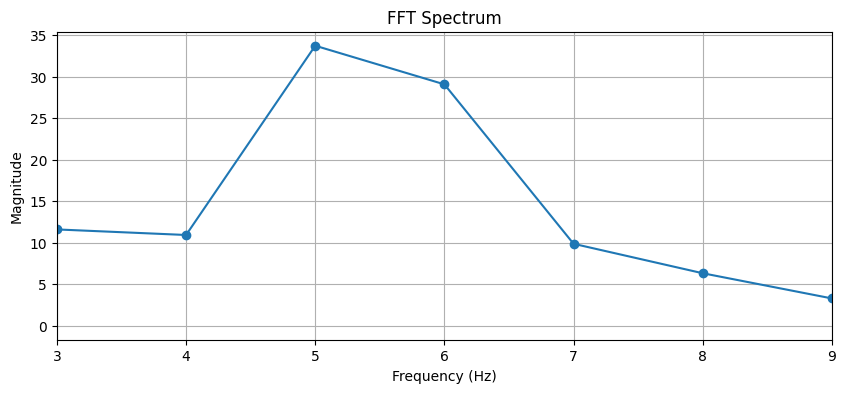

In [8]:
#M1의 결과를 그래프로 확인하자.

y_centered = y_noisy - np.mean(y_noisy)

N = len(y_centered)

spectrum = np.fft.rfft(y_centered)
freqs = np.fft.rfftfreq(N, d=1 / 100)
magnitude = np.abs(spectrum)
plt.figure(figsize=(10, 4))

plt.plot(
    freqs,
    magnitude,
    marker="o"
)

plt.xlim(3, 9)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT Spectrum")

plt.grid()
plt.show()

###**3단계. M2 — Parabolic Interpolation**

M2는 FFT peak의 위치를 더 세밀하게 추정하기 위한 보정 방법이다.(FFT + Parabolic Interpolation)

단순 FFT는 가장 높은 bin 하나만 선택하지만, parabolic interpolation은 peak와 그 좌우의 세 크기 값을 이용하여 그 사이에 포물선을 가정하기 때문이다.

세 점의 크기를 각각 `alpha : 왼쪽 bin`, `beta : FFT peak`,`gamma : 오른쪽 bin`이라고 할 때 `peak의 상대적 위치 delta`를 다음과 같이 추정한다.

- *delta = 0.5 × (alpha - gamma) / (alpha - 2 × beta + gamma)*

따라서 최종 주파수는

- *estimated_frequency = (k + delta) × fs / N*

로 계산한다.

In [9]:
def estimate_m2_parabolic(y, fs, fmin=4.0, fmax=8.0):

    y_centered = y - np.mean(y)
    N = len(y_centered)

    spectrum = np.fft.rfft(y_centered)

    freqs = np.fft.rfftfreq(N, d=1 / fs)
    magnitude = np.abs(spectrum)
    valid_idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
    k = valid_idx[np.argmax(magnitude[valid_idx])]

    # peak 양쪽 값이 없으면 보간 불가능
    if (k <= 0 or k >= len(magnitude) - 1):
        return freqs[k] * 60

    alpha = magnitude[k - 1]
    beta = magnitude[k]
    gamma = magnitude[k + 1]

    denominator = (alpha - 2 * beta + gamma)

    if abs(denominator) < 1e-12:
        delta = 0.0

    else:
        delta = (0.5 * (alpha - gamma) / denominator)

    estimated_frequency = (k + delta) * (fs / N)
    return estimated_frequency * 60

In [10]:
#M2 결과

m2_result = estimate_m2_parabolic(y_noisy, fs=100)

print("True BPM:", 330.0)
print("M1 FFT:", m1_result)
print("M2 Parabolic:", m2_result)

print("M2 Error:", abs(m2_result - 330.0))

True BPM: 330.0
M1 FFT: 300.0
M2 Parabolic: 319.82873276165253
M2 Error: 10.171267238347468


###**4단계. M3 — Autocorrelation**

Autocorrelation은 FFT처럼 주파수 스펙트럼을 직접 분석하지 않고, 시간 영역에서 신호의 반복 주기를 찾는다.

신호를 일정한 간격(lag)만큼 이동시키면서 원래 신호와 얼마나 비슷한지 계산한다. 주기적인 신호라면 한 주기에 해당하는 간격만큼 이동했을 때 다시 높은 유사도를 보일 수 있다.

이 코드에서 **lag**는 시간 자체가 아니라 **데이터 몇 칸만큼 이동했는지**를 뜻한다. 샘플링 주파수가 fs일 때 한 칸의 시간은 1 / fs초이므로

- 심박 주기(초) = `lag / fs`
- 심박 주파수(Hz) = `fs / lag`
- 심박수(bpm) = `60 × fs / lag`

이다.

275–388 bpm 범위를 기준으로 탐색할 lag 범위를 설정한다. 해당 범위 안에서 가장 큰 국소 자기상관 피크(local autocorrelation peak)(극댓값)를 선택하고, 국소 피크가 검출되지 않는 경우에는 탐색 범위 내에서 자기상관 값이 가장 큰 lag를 선택한다.

-> 신호를 조금씩 옮겨 보면서, 원래 신호와 다시 비슷해지는 지점들 중 가장 뚜렷한 지점을 찾는다.

선택한 lag를 `BPM = 60 × fs / lag`에 대입하여 심박수를 추정한다. 이를 통해 FFT와 다른 방식으로 반복 주기를 추정했을 때 성능이 어떻게 달라지는지 확인한다.

In [11]:
def estimate_m3_autocorr(y, fs, bpm_min=275.0, bpm_max=388.0):

    y_centered = y - np.mean(y)

    # 전체 autocorrelation
    corr = np.correlate(y_centered, y_centered, mode="full")

    # lag >= 0 부분만 사용
    corr = corr[len(y_centered) - 1:]

    # 정규화
    corr = corr / (corr[0] + 1e-12)

    # BPM 범위를 lag 범위로 변환
    min_lag = max(1,int(np.floor(fs / (bpm_max / 60))))
    max_lag = min(len(corr) - 1, int(np.ceil(fs / (bpm_min / 60))))

    # 검색 구간
    search_region = corr[min_lag: max_lag + 1]

    peaks, _ = find_peaks(search_region)

    if len(peaks) > 0:

        # 가장 큰 local peak 선택
        best_local_peak = peaks[np.argmax(search_region[peaks])]
        best_lag = (min_lag + best_local_peak)

    else:
        # local peak이 없으면
        # search region의 최대값 사용
        best_lag = (min_lag + np.argmax(search_region))

    estimated_bpm = (60 * fs / best_lag)
    return estimated_bpm

In [12]:
#M3 결과

m3_result = estimate_m3_autocorr(y_noisy, fs=100)

print("True BPM:", 330.0)
print("M3 Autocorrelation:", m3_result)

print("M3 Error:", abs(m3_result - 330.0))

True BPM: 330.0
M3 Autocorrelation: 333.3333333333333
M3 Error: 3.3333333333333144


###**5단계. M4 — 3rd-order Fourier Fitting**


M4는 선행 논문의 분석 절차를 참고한 방법이다.
먼저 M1의 FFT 결과로 기본 주파수의 초기값을 구한 뒤, 3차 Fourier 모델을 관측 신호에 맞춘다.

이 실험에서 사용하는 모델은 다음과 같다.

    y(t) = a0
         + a1 × cos(2π × f0 × t) + b1 × sin(2π × f0 × t)
         + a2 × cos(4π × f0 × t) + b2 × sin(4π × f0 × t)
         + a3 × cos(6π × f0 × t) + b3 × sin(6π × f0 × t)

여기서 `f0`는 추정하려는 기본 주파수이고, `2 × f0`와 `3 × f0`는 각각 2차·3차 harmonic의 주파수다. `a0`는 신호의 기준값이며, `a1`부터 `b3`까지는 각 파형의 크기와 모양을 조절하는 계수다.

코드는 FFT로 구한 주파수를 `f0`의 초기값으로 사용한다. 이후 Levenberg–Marquardt 방법을 이용해 `a0`, 각 harmonic의 계수, `f0`를 함께 조정하여 모델과 관측 신호의 차이를 줄인다. 최종적으로 추정된 `f0`에 60을 곱해 bpm으로 변환한다.

이 방법은 FFT bin 사이의 주파수도 추정할 수 있다. 코드에서는 fitting이 실패하거나 추정 결과가 200–500 bpm 범위를 벗어나면 M1의 FFT 결과를 반환하여 비정상 fitting 결과를 대체하였다.

In [13]:
def fourier_3rd_model( t, a0, a1, b1, a2, b2, a3, b3,f0):

    return (a0 + a1 * np.cos(2 * np.pi * f0 * t)
        + b1 * np.sin(2 * np.pi * f0 * t)
        + a2 * np.cos(4 * np.pi * f0 * t)
        + b2 * np.sin(4 * np.pi * f0 * t)
        + a3 * np.cos(6 * np.pi * f0 * t)
        + b3 * np.sin(6 * np.pi * f0 * t))

### 5-1. Nonlinear fitting 과정


먼저 M1의 FFT 결과를 이용해 대략적인 심박 주파수를 구하고, 이를 처음 시작값으로 사용한다.

그다음 `curve_fit`을 사용하여 만든 Fourier 함수가 실제 신호와 최대한 비슷해지도록 주파수와 계수 값을 조금씩 조정한다.

즉, 처음부터 정확한 주파수를 한 번에 계산하는 것이 아니라, 초기값에서 시작하여 신호와 더 잘 맞는 값을 반복적으로 찾는 방식이다.

본 코드에서는 SciPy의 `curve_fit`을 사용해 이 과정을 수행한다.

**주의점**

- Fitting이 수렴하지 않거나 200–500 bpm 범위를 벗어난 비정상적인 결과가 발생하면, 초기 FFT 결과를 반환하도록 설정하였다.


In [14]:
def estimate_m4_fitting(t, y, fs):


    # 1. FFT로 초기 주파수 추정
    m1_bpm = estimate_m1_fft(y, fs)
    f_init = m1_bpm / 60.0

    # 2. 초기 parameter
    p0 = [
        np.mean(y),   # a0
        0.0, 1.0,     # a1, b1
        0.3, 0.0,     # a2, b2
        0.1, 0.0,     # a3, b3
        f_init         # fundamental frequency
    ]

    try:

        popt, _ = curve_fit(fourier_3rd_model, t, y, p0=p0, method="lm", maxfev=5000)
        fitted_f0 = abs(popt[-1])
        fitted_bpm = (fitted_f0 * 60)

        # 비정상적 fitting 결과 방지
        if (fitted_bpm < 200 or fitted_bpm > 500):
            return m1_bpm

        return fitted_bpm

    except Exception:

        # fitting 실패 시 FFT 결과 사용
        return m1_bpm

###**6단계. M1~M4 한번에 비교**

지금까지 구현한 네 가지 방법을 동일한 330 bpm synthetic signal에 적용한다.

이 단계에서는 각 방법이 정상적으로 실행되는지 확인하고, 같은 신호에 대해 어떤 값을 출력하는지 간단히 비교한다.

정확한 성능 비교는 이후 여러 BPM, noise level, observation duration 조건에서 반복 실험을 수행하는 benchmark 단계에서 진행한다.

In [15]:
m1_result = estimate_m1_fft(y_noisy, FS)
m2_result = estimate_m2_parabolic(y_noisy, FS)
m3_result = estimate_m3_autocorr(y_noisy, FS)
m4_result = estimate_m4_fitting(t, y_noisy, FS)

print("Ground Truth:", 330.0)
print()

print("M1 FFT:", m1_result)
print("M2 Parabolic:", m2_result)
print("M3 Autocorrelation:", m3_result)
print("M4 Fourier Fitting:", m4_result)

Ground Truth: 330.0

M1 FFT: 300.0
M2 Parabolic: 319.82873276165253
M3 Autocorrelation: 333.3333333333333
M4 Fourier Fitting: 329.81712885849083


In [16]:
#절대 오차 비교

true_bpm = 330.0

print("M1 Error:", abs(m1_result - true_bpm))
print("M2 Error:", abs(m2_result - true_bpm))
print("M3 Error:", abs(m3_result - true_bpm))
print("M4 Error:", abs(m4_result - true_bpm))

M1 Error: 30.0
M2 Error: 10.171267238347468
M3 Error: 3.3333333333333144
M4 Error: 0.1828711415091675


### **7단계. 반복 Benchmark 실험 조건**

여기까지의 테스트는 심박수를 330bpm으로 설정하고 진행하였다.

이후의 실험은 선행 논문에서 대조군의 심박수 분포를 설명하며 제시한 생리적 범위(274.9–388.1 bpm)를 참고하여, 시뮬레이션의 실제 심박수(true BPM) 범위를 설정하였다.

각 실험에서는 이 범위 안에서 심박수를 무작위로 선택한다. 이는 여러 심박수에서 각 추정 방법의 성능을 비교하기 위한 설정이다.

### Observation Duration

- 0.5 s
- 1.0 s
- 2.0 s

1초는 선행 논문의 관측 조건이며, 0.5초와 2초는 관측 시간이 달라졌을 때 추정 결과가 어떻게 변하는지 확인하기 위해 추가하였다.

DFT의 기본 frequency-bin spacing은 `Δf = 1 / T` 이므로,
0.5 s → 2 Hz, 1.0 s → 1 Hz, 2.0 s → 0.5 Hz가 된다.

따라서 관측시간 증가가 성능에 어떤 영향을 주는지 확인할 수 있다.

### Noise Level

Gaussian noise의 표준편차를 다음과 같이 설정한다.

- Clean = 0.0
- Low = 0.2
- Medium = 0.5
- High = 0.8

이 값들은 noise 증가에 따른 변화를 관찰하기 위해 임의로 설정한 조건이다.

### Number of Trials

각 조건을 30회 반복한다.

- 임의로 설정한 simulation 반복 횟수이며, 매 시행에서 서로 다른 심박수와 noise를 사용하여 전체적인 결과의 경향을 확인하기 위한 것이다.

In [17]:
durations = [0.5, 1.0, 2.0]

noise_levels = {
    "Clean": 0.0,
    "Low": 0.2,
    "Medium": 0.5,
    "High": 0.8
}

N_TRIALS = 30

rng = np.random.default_rng(seed=35)

results = []

### **8단계. 반복 Simulation 실행**

각 관측 시간과 노이즈 조건에 대해 다음 과정을 반복한다.

    1. 275–388 bpm 범위에서 실제 심박수(Ground Truth BPM)를 무작위로 생성한다.
    2. 해당 심박수를 갖는 synthetic heartbeat signal을 생성한다.
    3. 동일한 신호를 M1, M2, M3, M4에 각각 입력한다.
    4. 각 방법에서 추정한 심박수(Estimated BPM)를 구한다.
    5. 실제 심박수와 추정 심박수의 차이인 Absolute Error를 계산한다.
    6. 각 방법의 실행 시간을 ms단위로 측정한다.
    7. 각 실험의 결과를 하나의 table에 저장한다.


In [18]:
for duration in durations:

    for noise_name, noise_std in noise_levels.items():

        for trial in range(N_TRIALS):

            # Ground Truth BPM 생성
            true_bpm = rng.uniform(BPM_MIN, BPM_MAX)


            # 동일한 synthetic signal 생성
            t_trial, y_trial, _ = generate_daphnia_signal(
                duration=duration,
                fs=FS,
                true_bpm=true_bpm,
                noise_std=noise_std,
                rng=rng
            )

            # M1
            start = time.perf_counter()
            est_m1 = estimate_m1_fft(y_trial, FS)
            time_m1 = (time.perf_counter() - start) * 1000

            # M2
            start = time.perf_counter()
            est_m2 = estimate_m2_parabolic(y_trial, FS)
            time_m2 = (time.perf_counter() - start) * 1000

            # M3
            start = time.perf_counter()
            est_m3 = estimate_m3_autocorr(y_trial, FS)
            time_m3 = (time.perf_counter() - start) * 1000


            # M4
            start = time.perf_counter()
            est_m4 = estimate_m4_fitting(t_trial, y_trial, FS)
            time_m4 = (time.perf_counter() - start) * 1000

            estimates = { "M1_FFT": (est_m1, time_m1),
                          "M2_Parabolic": (est_m2, time_m2),
                          "M3_Autocorrelation": (est_m3, time_m3),
                          "M4_Fourier_Fitting": (est_m4, time_m4)}

            # 결과 저장

            for method, (estimate, latency) in estimates.items():

                absolute_error = abs(estimate - true_bpm)

                results.append({
                    "Duration": duration,
                    "Noise": noise_name,
                    "Trial": trial,
                    "Method": method,
                    "True_BPM": true_bpm,
                    "Estimated_BPM": estimate,
                    "Absolute_Error":absolute_error,
                    "Success_6bpm":absolute_error <= 6,
                    "Latency_ms":latency})
                # OptimizeWarning은 covariance 추정 관련 경고이며, 본 실험에서는 fitted frequency만 사용한다.

/tmp/ipykernel_1048/1379273706.py:19: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(fourier_3rd_model, t, y, p0=p0, method="lm", maxfev=5000)


**Simulation 결과 정리**

실험 결과를 Pandas DataFrame으로 정리하였다. 각 행에는 관측 시간, 노이즈 수준, 시행 번호, 추정 방법, 실제·추정 심박수, 절대 오차, ±6 bpm 이내 추정 여부, 실행 시간이 저장된다.

총 3가지 관측 시간 × 4가지 노이즈 수준 × 30회 반복 = 360개의 신호를 생성하였다. 각 신호에 4가지 추정 방법을 적용했으므로 결과는 총 360 × 4 = **1,440행**이다.

In [19]:
df = pd.DataFrame(results)

print("Total number of results:",len(df))

display(df.head(10))

Total number of results: 1440


,Duration,Noise,Trial,Method,True_BPM,Estimated_BPM,Absolute_Error,Success_6bpm,Latency_ms
0,0.5,Clean,0,M1_FFT,313.188300,360.000000,4.681170e+01,False,0.270643
1,0.5,Clean,0,M2_Parabolic,313.188300,321.779923,8.591623e+00,False,0.108336
2,0.5,Clean,0,M3_Autocorrelation,313.188300,315.789474,2.601174e+00,True,0.145733
3,0.5,Clean,0,M4_Fourier_Fitting,313.188300,313.188300,1.192097e-08,True,4.959821
4,0.5,Clean,1,M1_FFT,334.592775,360.000000,2.540722e+01,False,0.199809
5,0.5,Clean,1,M2_Parabolic,334.592775,351.497432,1.690466e+01,False,0.153321
6,0.5,Clean,1,M3_Autocorrelation,334.592775,333.333333,1.259442e+00,True,0.156566
7,0.5,Clean,1,M4_Fourier_Fitting,334.592775,334.592775,3.036877e-08,True,4.697601
8,0.5,Clean,2,M1_FFT,370.591513,360.000000,1.059151e+01,False,0.201180
9,0.5,Clean,2,M2_Parabolic,370.591513,360.762463,9.829050e+00,False,0.113862


In [20]:
df_1s = df[df["Duration"] == 1.0].copy()
print("Number of 1-second results:",len(df_1s)) #1초 관측 조건의 결 추출

Number of 1-second results: 480


### **8.1 1초 조건의 성능 요약**

1초 observation condition에서 각 Noise × Method 조합별로 30회의 반복 결과를 하나의 통계값으로 요약한다.

각 그룹에 대해 다음 네 지표를 계산한다.

- **MAE (Mean Absolute Error)**  
  실제 BPM과 추정 BPM 사이의 절대오차 평균. 이 숫자가 작을 수록 정확도가 높다고 보면 된다.

- **STD (Standard Deviation of Absolute Error)**  
  반복 실험에서 오차가 얼마나 변동하는지를 나타낸다.

- **Success Rate (±6 bpm)**  
  추정 오차가 ±6 bpm 이하였던 trial의 비율이다.

- **Average Latency**  
  한 번의 심박수 추정에 필요한 평균 연산시간이다.


In [21]:
summary_1s = (df_1s.groupby(["Noise", "Method"]).agg(

    MAE=(
            "Absolute_Error",
            "mean"
        ),

    STD=(
            "Absolute_Error",
            "std"
        ),

    Success_Rate=(
            "Success_6bpm",
            "mean"
        ),

    Avg_Latency_ms=(
            "Latency_ms",
            "mean"
        )

    ).reset_index())

summary_1s["Success_Rate"] *= 100
display(summary_1s.round(3))

,Noise,Method,MAE,STD,Success_Rate,Avg_Latency_ms
0,Clean,M1_FFT,15.311,8.175,20.000,0.109
1,Clean,M2_Parabolic,9.206,3.477,20.000,0.068
2,Clean,M3_Autocorrelation,5.061,3.142,60.000,0.094
3,Clean,M4_Fourier_Fitting,0.000,0.000,100.000,2.879
4,High,M1_FFT,13.699,8.254,20.000,0.155
5,High,M2_Parabolic,10.044,6.258,33.333,0.080
6,High,M3_Autocorrelation,9.979,7.578,40.000,0.124
7,High,M4_Fourier_Fitting,3.074,2.445,90.000,5.970
8,Low,M1_FFT,14.760,8.256,16.667,0.108
9,Low,M2_Parabolic,9.013,3.787,23.333,0.068


### **8.2 Noise level에 따른 MAE 비교**

1초 observation condition에서 noise가 증가할 때 각 알고리즘의 MAE가 어떻게 변화하는지 확인한다.





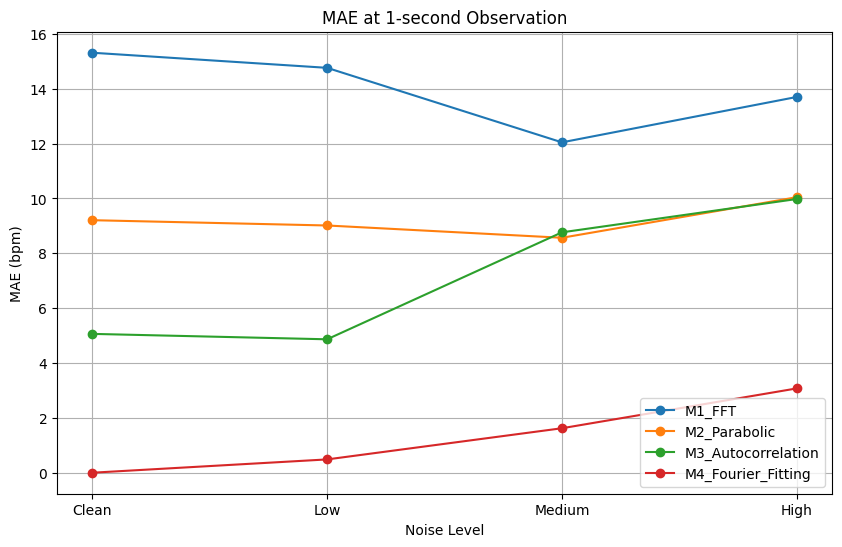

In [22]:
noise_order = ["Clean","Low","Medium","High"]

methods = ["M1_FFT","M2_Parabolic","M3_Autocorrelation","M4_Fourier_Fitting"]

plt.figure(figsize=(10, 6))

for method in methods:

    sub = df_1s[df_1s["Method"] == method]

    values = (sub.groupby("Noise")["Absolute_Error"].mean().reindex(noise_order))

    plt.plot(
        noise_order,
        values,
        marker="o",
        label=method
    )

plt.xlabel("Noise Level")

plt.ylabel("MAE (bpm)")

plt.title("MAE at 1-second Observation")

plt.legend()
plt.grid()

plt.show()

### **8.3 ±6 bpm 이내 추정 성공률 비교**

각 noise condition에서 추정 오차가 ±6 bpm 이내에 들어온 실행의 비율을 비교한다.

MAE가 평균적인 오차 크기를 보여준다면, Success Rate는 실용적으로 일정 범위 안에 들어오는 추정이 얼마나 자주 발생하는가를 보여준다.


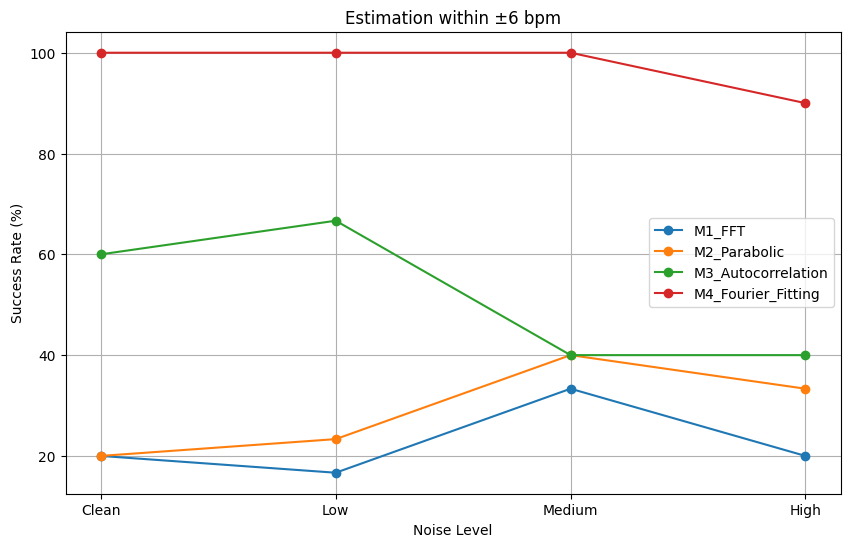

In [23]:
plt.figure(figsize=(10, 6))

for method in methods:

    sub = df_1s[df_1s["Method"]==method]

    values = (sub.groupby("Noise")["Success_6bpm"].mean().reindex(noise_order) * 100)

    plt.plot(
        noise_order,
        values,
        marker="o",
        label=method
    )

plt.xlabel("Noise Level")
plt.ylabel("Success Rate (%)")

plt.title("Estimation within ±6 bpm")

plt.legend()
plt.grid()

plt.show()

### **8.4 관측 시간의 영향**

0.5초, 1초, 2초의 관측 시간에서 각 방법의 평균 MAE를 비교한다.

FFT의 주파수 해상도는 `Δf = 1/T`이므로, 관측 시간이 길어질수록 더 세밀한 주파수 구분이 가능하다.

- 0.5초 → Δf = 2 Hz → 120 bpm 간격
- 1초 → Δf = 1 Hz → 60 bpm 간격
- 2초 → Δf = 0.5 Hz → 30 bpm 간격

따라서 관측 시간이 증가했을 때 각 심박수 추정 방법의 오차가 어떻게 달라지는지 비교하고, 특히 FFT 기반 방법이 향상된 주파수 해상도의 영향을 얼마나 받는지를 탐구할 수 있다.


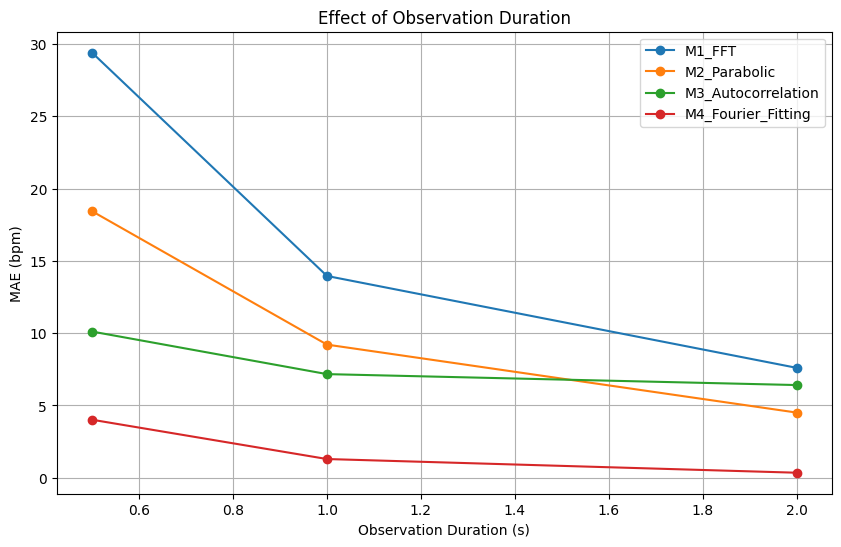

In [24]:
duration_summary = (df.groupby(["Duration","Method"])["Absolute_Error"].mean().reset_index())

plt.figure(figsize=(10, 6))

for method in methods:

    sub = duration_summary[duration_summary["Method"]== method]

    plt.plot(
        sub["Duration"],
        sub["Absolute_Error"],
        marker="o",
        label=method
    )

plt.xlabel("Observation Duration (s)")
plt.ylabel("MAE (bpm)")

plt.title("Effect of Observation Duration")

plt.legend()
plt.grid()

plt.show()

###**8.5 Algorithm별 평균 실행시간 비교**

각 심박수 추정 방법이 한 번의 수행에 걸린 평균 시간을 계산한다.

In [25]:
latency_summary = (df_1s.groupby("Method")["Latency_ms"].mean().sort_values())

display(latency_summary)

,Latency_ms
Method,
M2_Parabolic,0.072983
M3_Autocorrelation,0.101578
M1_FFT,0.123884
M4_Fourier_Fitting,4.018152


### Execution Time 시각화

각 method의 평균 latency를 bar 그래프로 비교한다.


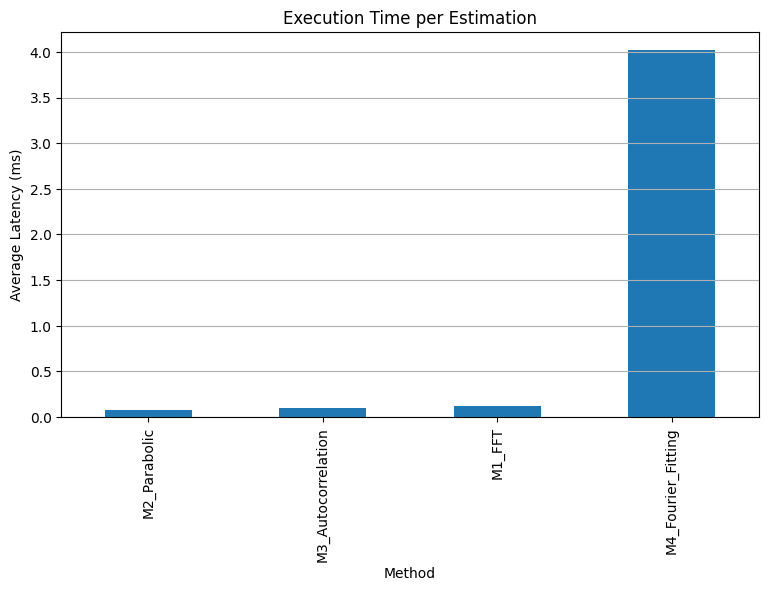

In [26]:
plt.figure(figsize=(9, 5))

latency_summary.plot(kind="bar")

plt.ylabel("Average Latency (ms)")
plt.title("Execution Time per Estimation")
plt.grid(axis="y")

plt.show()

### **9단계. Results & Interpretation**

합성 신호를 이용해 네 가지 심박수 추정 방법을 비교한 결과, 방법에 따라 추정 오차와 noise의 영향, 실행 시간에서 차이가 나타났다.

1. **FFT Peak(M1)**

M1은 전반적으로 다른 방법보다 큰 추정 오차를 보였다. 특히 관측 시간이 짧을 때 FFT가 구분할 수 있는 주파수 간격이 넓기 때문에, 실제 심박수가 그 사이에 위치하면 오차가 커질 수 있음을 확인하였다.

관측 시간이 길어질수록 FFT가 더 세밀하게 주파수를 구분할 수 있어 오차가 줄어드는 경향도 확인할 수 있었다.

2. **Parabolic Interpolation(M2)**

M2는 대부분의 조건에서 M1보다 낮은 오차를 보였다.

이는 FFT에서 가장 큰 peak만 선택하는 대신, peak 주변 값을 함께 이용해 위치를 보정하는 과정이 추정 오차를 줄이는 데 도움이 되었기 때문으로 볼 수 있다.

3. **Autocorrelation(M3)**

M3는 신호의 반복 주기를 이용하여 심박수를 추정하였으며, noise가 낮은 조건에서는 비교적 작은 오차를 보였다.

하지만 noise가 증가하면 반복 주기를 정확하게 찾기 어려워지면서 오차도 커지는 경향이 나타났다.

4. **Third-order Fourier Fitting(M4)**

M4는 전반적으로 가장 작은 추정 오차를 보였다.

다만 synthetic signal 자체가 M4에서 사용하는 Fourier model과 비슷한 형태로 만들어졌기 때문에, M4에 유리한 실험 조건이었다는 점을 고려해야 한다.

또한 M4는 다른 방법보다 실행 시간이 더 길게 나타났다. 따라서 이번 실험에서는 정확도를 높이는 대신 더 많은 계산이 필요한 특징을 확인할 수 있었다.

5. **종합**

M1보다 M2와 M3가 더 낮은 오차를 보이는 경우가 많았고, M4는 전반적으로 가장 낮은 오차를 보였다.

하지만 각 방법은 서로 다른 특징과 한계를 가지고 있으며, 특히 M4는 synthetic signal의 생성 방식과 비슷한 model을 사용했다는 점에서 결과를 그대로 일반화하기는 어렵다.

이번 실험을 통해 심박수 추정 방법에 따라 정확도와 실행 시간에서 서로 다른 결과가 나타날 수 있음을 확인하였다.




###**10단계. Limitations**

1. **합성 신호와 실제 영상 신호의 차이**

    본 실험은 정답 심박수를 설정할 수 있는 합성 신호를 사용했다. 실제 Daphnia magna 영상에서는 개체의 움직임, 심장 ROI의 위치 변화, 조명 변화, 초점 이탈, 신호 기준선의 변화가 함께 발생할 수 있다. 따라서 현재의 오차를 실제 영상 분석의 정확도로 일반화할 수 없다.


2. **노이즈와 평가 기준의 해석 범위**

    noise_std 값은 실제 현미경 영상에서 측정한 잡음 수준이 아니라 이번 시뮬레이션을 위해 설정한 값이다. ±6 bpm 이내 추정 비율 역시 방법 간 비교를 위한 자체 기준이며, 선행 논문의 공식 정확도 요구 조건은 아니다. 선행 논문에서 사용한 6 bpm의 histogram bin width와도 목적이 다르다.

3. **M4의 fallback 처리**

    M4에서는 fitting 결과가 설정한 범위를 벗어나거나 fitting이 실패한 경우 M1의 FFT 결과를 대신 반환하도록 구현하였다. 이 방식은 비정상적인 추정값을 방지할 수 있지만, M4에만 다른 방법과 다른 예외 처리 조건이 적용된다는 한계가 있다. 따라서 현재 결과에서는 M4의 오차나 안정성이 실제 fitting 자체의 성능보다 좋게 나타날 가능성이 있다. 이후에는 fallback이 발생한 경우를 별도로 기록하거나, fallback 결과를 성능 평가에서 분리하여 비교하는 방법을 검토할 필요가 있다.
    

4. **실행 시간**

    Colab에서 측정한 함수 실행 시간은 실제 카메라, 현미경 및 자동화 시스템의 전체 처리 시간을 포함하지 않는다. 영상 획득, ROI 선택, 신호 추출, 심박수 계산을 포함한 파이프라인 전체의 처리 시간이 별도로 필요하다.



## References
Kwon, I. H., Kim, Y., Sung, S.-E., Park, S., Park, G., Ko, S., Yim, Y.-H.,
Tegegn, G. B., Lee, S.-W., Heo, M. B., Lee, T. G., & Kim, Y. J. (2026).

High-throughput heart rate monitoring in Daphnia magna for sublethal ecotoxicological assessment. Journal of Hazardous Materials, 505, 141474. https://doi.org/10.1016/j.jhazmat.2026.141474